In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
import copy

In [3]:
insta=5
np.random.seed(126)
depcentral = pd.read_excel(r"DATOS.xlsx",sheet_name='deposito central')
pacientes = pd.read_excel(r"DATOS.xlsx",sheet_name='Pacientes',index_col=2)
eco=pd.read_excel(r"DATOS.xlsx",sheet_name='eco capital')
durserv=pd.read_excel(r"DATOS.xlsx",sheet_name='demanda'
                     ,usecols='N:O',nrows=5,index_col=0)
demanda=pd.read_excel(r"DATOS.xlsx",sheet_name='demanda'
                     ,usecols='A:F',nrows=100,index_col=0)
tiempos=pd.read_excel(r'TIEMPOS.xlsx',sheet_name='tiempos',index_col=0)
durserv.columns=['t']
limtiemp=6*60
limkits=36

In [4]:
#################FUNCIONES IMPLEMENTADAS EN EL CODIGO################################
def rta_asig(rutas_optmizadas_2, rta_rutas_optmizadas_2):
    filas = []
    for i in range(len(rutas_optmizadas_2)):
        rut = rutas_optmizadas_2[i][1]           
        costo = rutas_optmizadas_2[i][0]        

        for j in range(rut.shape[0]):
            cliente = rut.iat[j, 0]
            ruta    = rut.iat[j, 1]
            dia     = rut.iat[j, 2]

            print(cliente)
            print(ruta)
            print(dia)

            filas.append({
                'cliente': cliente,
                'costo':   costo,
                'ruta':    ruta,
                'día':     dia
            })

    nuevo_df = pd.DataFrame(filas, columns=['cliente', 'costo', 'ruta', 'día'])

    return pd.concat([rta_rutas_optmizadas_2, nuevo_df], ignore_index=True)


#########################################################################################################

def rta_asig_costos(rutas_optmizadas, rta_rutas_optmizadas_costos):

    filas = []
    for i in range(len(rutas_optmizadas)):
        rut = rutas_optmizadas[i][1]
        costo = rutas_optmizadas[i][0]

        cliente = rut.iat[0, 0]
        ruta    = rut.iat[0, 1]
        dia     = rut.iat[0, 2]

        print(cliente, costo, ruta)

        filas.append({
            'cliente': cliente,
            'costo':   costo,
            'ruta':    ruta,
            'día':     dia
        })

    nuevo_df = pd.DataFrame(filas, columns=['cliente', 'costo', 'ruta', 'día'])
    return pd.concat([rta_rutas_optmizadas_costos, nuevo_df], ignore_index=True)

#########################################################################################################

def swap(Cost, temp):
    newRoute = copy.deepcopy(temp)
    n = newRoute.shape[0]
    D = distancias[num_bodega][0]

    delta = 0.0
    bestI = -1
    bestJ = -1

    for i in range(1, n - 2):            
        nodoI   = newRoute.iat[i, 0]
        predI   = newRoute.iat[i - 1, 0]
        sucI    = newRoute.iat[i + 1, 0]

        for j in range(i + 1, n - 2):    
            nodoJ = newRoute.iat[j, 0]
            predJ = newRoute.iat[j - 1, 0]
            sucJ  = newRoute.iat[j + 1, 0]

            if j == i + 1:
          
                d = (D.loc[predI, nodoJ] + D.loc[nodoJ, nodoI] + D.loc[nodoI, sucJ]
                     - D.loc[predI, nodoI] - D.loc[nodoI, nodoJ] - D.loc[nodoJ, sucJ])
            else:
                d = (D.loc[predI, nodoJ] + D.loc[nodoJ, sucI]
                     + D.loc[predJ, nodoI] + D.loc[nodoI, sucJ]
                     - D.loc[predI, nodoI] - D.loc[nodoI, sucI]
                     - D.loc[predJ, nodoJ] - D.loc[nodoJ, sucJ])

            if d < delta:
                delta = d
                bestI = i
                bestJ = j

    if bestI == -1:
        return [Cost, newRoute, False]

    newRoute.iat[bestI, 0], newRoute.iat[bestJ, 0] = \
        newRoute.iat[bestJ, 0], newRoute.iat[bestI, 0]

    return [Cost + delta, newRoute, True]

#########################################################################################################
def suma_costo(R_optmizadas):
    costo_total=0
    for i in range(len(R_optmizadas)):
        costo_total+=R_optmizadas[i][0]
    return costo_total
#########################################################################################################

def conteo_split(I,J,newRoute):
    dif= J-I
    costo_split=0
    for i in range(dif):
        d=distancias[num_bodega][0].loc[newRoute.iat[I+i,0],newRoute.iat[I+i+1,0]] 
        costo_split+= d
    return costo_split
    

#########################################################################################################

def conteo_quieto(I,J,newRoute):
    dif= J-I
    costo_split=0
    for i in range(dif):
        d=distancias[num_bodega][0].loc[newRoute.iat[I+i,0],newRoute.iat[I+i+1,0]] 
        costo_split+= d
    return costo_split
    
#########################################################################################################
def twoOptimal_1(Cost, ruta):

    newRoute = copy.deepcopy(ruta)
    n = newRoute.shape[0]
    D = distancias[num_bodega][0]

    delta = 0.0
    bestI = -1
    bestJ = -1


    for i in range(1, n - 3):
        predTail = ruta.iat[i,     0]
        tail     = ruta.iat[i + 1, 0]

        for j in range(i + 2, n - 2):
            head    = ruta.iat[j,     0]
            sucHead = ruta.iat[j + 1, 0]

            delta_cand = (D.loc[predTail, head]
                          + D.loc[tail,     sucHead]
                          - D.loc[predTail, tail]
                          - D.loc[head,     sucHead])

            if delta_cand < delta:
                delta = delta_cand
                bestI = i + 1  
                bestJ = j       


    if bestI == -1:
        return [Cost, newRoute, False]


    newCost = Cost + delta

    lo = bestI
    hi = bestJ
    while lo < hi:
        newRoute.iat[lo, 0], newRoute.iat[hi, 0] = \
            newRoute.iat[hi, 0], newRoute.iat[lo, 0]
        lo += 1
        hi -= 1



    if newCost >= Cost:
        return [Cost, copy.deepcopy(ruta), False]

    return [newCost, newRoute, True]
#########################################################################################################

In [5]:
#################FUNCIONES IMPLEMENTADAS EN EL CODIGO################################

def uno_Mcolor_grafica (rutas_optmizadas,bodega):
    COOD_X=[]
    COOD_Y=[]

    for i in range ( len(rutas_optmizadas)):
        Ruta=copy.deepcopy(rutas_optmizadas[i][1])
        if Ruta.iat[0,0] == bodega:
            for j in range ( Ruta.shape[0]):
                client=Ruta.iat[j,0]
                COOD_X.append(pacientes.loc[ client , 'Latitud' ])
                COOD_Y.append(pacientes.loc[ client , 'Longitud' ])

            plt.plot(COOD_X,COOD_Y)
            COOD_X=[]
            COOD_Y=[]
            
#############################################################################################################
def uno_UNIcolor_grafica (R_optmizadas,bodega):
    COOD_X=[]
    COOD_Y=[]

    for i in range ( len(R_optmizadas)):
        Ruta=copy.deepcopy(R_optmizadas[i][1])
        if Ruta.iat[0,0] == bodega:
            for j in range ( Ruta.shape[0]):
                client=Ruta.iat[j,0]
                COOD_X.append(pacientes.loc[ client , 'Latitud' ])
                COOD_Y.append(pacientes.loc[ client , 'Longitud' ])

    plt.plot(COOD_X,COOD_Y)

    
    
    
    
    
#############################################################################################################
def uno_UNIcolor_grafica_combinadas (R_optmizadas_1, R_optmizadas_2 ,bodega):
    COOD_X=[]
    COOD_Y=[]

    for i in range ( len(R_optmizadas_1)):
        Ruta=copy.deepcopy(R_optmizadas_1[i][1])
        if Ruta.iat[0,0] == bodega:
            for j in range ( Ruta.shape[0]):
                client=Ruta.iat[j,0]
                COOD_X.append(pacientes.loc[ client , 'Latitud' ])
                COOD_Y.append(pacientes.loc[ client , 'Longitud' ])

    plt.plot(COOD_X,COOD_Y)
    
    COOD_X=[]
    COOD_Y=[]

    for i in range ( len(R_optmizadas_2)):
        Ruta=copy.deepcopy(R_optmizadas_2[i][1])
        if Ruta.iat[0,0] == bodega:
            for j in range ( Ruta.shape[0]):
                client=Ruta.iat[j,0]
                COOD_X.append(pacientes.loc[ client , 'Latitud' ])
                COOD_Y.append(pacientes.loc[ client , 'Longitud' ])

    plt.plot(COOD_X,COOD_Y)

#############################################################################################################
def uno_Mcolor_grafica_dia_especi (R_optmizadas,bodega, temp_dia):
    COOD_X=[]
    COOD_Y=[]

    for i in range ( len(R_optmizadas)):
        Ruta=copy.deepcopy(R_optmizadas[i][1])
        #print(Ruta)
        if Ruta.iat[0,0] == bodega and Ruta.iat[0,2]== temp_dia :
            for j in range ( Ruta.shape[0]):
                client=Ruta.iat[j,0]
                COOD_X.append(pacientes.loc[ client , 'Latitud' ])
                COOD_Y.append(pacientes.loc[ client , 'Longitud' ])

            plt.plot(COOD_X,COOD_Y)
            COOD_X=[]
            COOD_Y=[]
#############################################################################################################
def uno_UNI_grafica_dia_especi_combinados (R_optmizadas_1, R_optmizadas_2,bodega, temp_dia):
    COOD_X=[]
    COOD_Y=[]

    for i in range ( len(R_optmizadas_1)):
        Ruta=copy.deepcopy(R_optmizadas_1[i][1])
        #print(Ruta)
        if Ruta.iat[0,0] == bodega and Ruta.iat[0,2]== temp_dia :
            for j in range ( Ruta.shape[0]):
                client=Ruta.iat[j,0]
                COOD_X.append(pacientes.loc[ client , 'Latitud' ])
                COOD_Y.append(pacientes.loc[ client , 'Longitud' ])

    plt.plot(COOD_X,COOD_Y)
    
    COOD_X=[]
    COOD_Y=[]

    for i in range ( len(R_optmizadas_2)):
        Ruta=copy.deepcopy(R_optmizadas_2[i][1])
        #print(Ruta)
        if Ruta.iat[0,0] == bodega and Ruta.iat[0,2]== temp_dia :
            for j in range ( Ruta.shape[0]):
                client=Ruta.iat[j,0]
                COOD_X.append(pacientes.loc[ client , 'Latitud' ])
                COOD_Y.append(pacientes.loc[ client , 'Longitud' ])

    plt.plot(COOD_X,COOD_Y)
#############################################################################################################
def menu_graficas(R_optmizadas):
    bandera= False
    print("indique que bodega desea ver entre B1, B2 Ó B3")
    bodega=input("Indique la bodega")
    dia =int(input("si decia ver todos los dias de semana marque 1, si decia ver un dia en especifico marque 2"))
    while dia<1 or dia>2:
        dia =int(input("si decia ver todos los dias de semana marque 1, si decia ver un dia en especifico marque 2"))
    if dia==1:
        if bodega == 'B1':
            uno_Mcolor_grafica (R_optmizadas,bodega)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        elif bodega == 'B2':
            uno_Mcolor_grafica (R_optmizadas,bodega)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        elif bodega == 'B3':
            uno_Mcolor_grafica (R_optmizadas,bodega)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        else:
            print("NO SE ENCONTRO LA BODEGA")
    else:
        dias_list=['Lunes', 'Martes', 'Miércoles', 'Jueves','Viernes']
        print('Indique el dia de la semana: Lunes , Martes, Miércoles, Jueves ó Viernes')
        temp_dia=input("Indique el dia")
        while temp_dia not in dias_list:
            print('Indique el dia de la semana: Lunes , Martes, Miércoles, Jueves ó Viernes')
            temp_dia=input("Indique el dia")

        if bodega == 'B1':
            uno_Mcolor_grafica_dia_especi (R_optmizadas,bodega, temp_dia)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        elif bodega == 'B2':
            uno_Mcolor_grafica_dia_especi (R_optmizadas,bodega, temp_dia)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        elif bodega == 'B3':
            uno_Mcolor_grafica_dia_especi (R_optmizadas,bodega, temp_dia)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        else:
            print("NO SE ENCONTRO LA BODEGA")
    print("//////////////////")
#############################################################################################################
def menu_graficas_combinadas(R_optmizadas_1, R_optmizadas_2):
    bandera= False
    print("indique que bodega desea ver entre B1, B2 Ó B3")
    bodega=input("Indique la bodega")
    dia =int(input("si decia ver todos los dias de semana marque 1, si decia ver un dia en especifico marque 2"))
    while dia<1 or dia>2:
        dia =int(input("si decia ver todos los dias de semana marque 1, si decia ver un dia en especifico marque 2"))
    if dia==1:
        if bodega == 'B1':
            uno_UNIcolor_grafica_combinadas (R_optmizadas_1, R_optmizadas_2 ,bodega)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        elif bodega == 'B2':
            uno_UNIcolor_grafica_combinadas (R_optmizadas_1, R_optmizadas_2 ,bodega)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        elif bodega == 'B3':
            uno_UNIcolor_grafica_combinadas (R_optmizadas_1, R_optmizadas_2 ,bodega)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        else:
            print("NO SE ENCONTRO LA BODEGA")
    else:
        dias_list=['Lunes', 'Martes', 'Miércoles', 'Jueves','Viernes']
        print('Indique el dia de la semana: Lunes , Martes, Miércoles, Jueves ó Viernes')
        temp_dia=input("Indique el dia")
        while temp_dia not in dias_list:
            print('Indique el dia de la semana: Lunes , Martes, Miércoles, Jueves ó Viernes')
            temp_dia=input("Indique el dia")

        if bodega == 'B1':
            uno_UNI_grafica_dia_especi_combinados (R_optmizadas_1, R_optmizadas_2,bodega, temp_dia)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        elif bodega == 'B2':
            uno_UNI_grafica_dia_especi_combinados (R_optmizadas_1, R_optmizadas_2,bodega, temp_dia)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        elif bodega == 'B3':
            uno_UNI_grafica_dia_especi_combinados (R_optmizadas_1, R_optmizadas_2,bodega, temp_dia)
            print("EL GRAFICO SE MOSTRARA AL SALIR DEL MENU  PRINCIPAL")
        else:
            print("NO SE ENCONTRO LA BODEGA")
    print("//////////////////")
#############################################################################################################

In [6]:
####ASIGNACION DE CLIENTES A BODEGAS
distancias=[]

tabdistan=tiempos.loc[:,['B1','B2','B3']].copy()
lista=[]
for cliente in tabdistan.index:
    a=tabdistan.loc[cliente,:].idxmin()
    lista.append(a)
tabdistan['bodega asignada']=lista
tabdistan.loc['Eco','bodega asignada']='B1'


In [7]:
#FILTRAR ASIGNACION PARA CADA BODEGA
tabdistan.iloc[-1,-1]='B1'
b1clie=tabdistan[((tabdistan['bodega asignada']=='B1'))]
tabdistan.iloc[-1,-1]='B2'
b2clie=tabdistan[((tabdistan['bodega asignada']=='B2')| (tabdistan['bodega asignada']==np.nan))]
tabdistan.iloc[-1,-1]='B3'
b3clie=tabdistan[((tabdistan['bodega asignada']=='B3')| (tabdistan['bodega asignada']==np.nan))]
globa= [b1clie,b2clie,b3clie]
#globa

In [8]:
#MATRIZ CON LAS DISTANCIAS DE CLIENTE A CLIENTE Y DE CLIENTE A BODEGA JUNTO CON EL DEPOSITO PARA CADA UNA BODEGA EN ESPECIFICO
distancias=[]
for bodega in globa:
    matrix=[]
    for cust in bodega.index:
        parcial=[]
        for othercust in bodega.index:
            if cust==othercust:
                distan=np.nan
            else:
                distan=tiempos.loc[cust,othercust]
            parcial.append(distan)
        matrix.append(parcial)
    

    hola=pd.DataFrame(matrix)
    hola.index=bodega.index
    hola.columns=bodega.index
    distancias.append([hola])
#distancias

In [9]:
#CREACION DE LAS 3 GRANDES RUTAS
subrutas=[]
i=1
for datos in distancias:
    ruta = []
    costoRuta = 0
    primerNodo = 'B'+str(i)
    costo0=datos[0].copy()
    costo0= costo0.drop(primerNodo,axis=1)
    nodoActual = primerNodo
    ruta.append(primerNodo)
    while costo0.shape[1] > 0:
        candidato=costo0.loc[nodoActual,:].idxmin()
        if costo0.shape[1] !=1 and candidato== 'Eco':
            costo0.loc[nodoActual,'Eco']=np.nan
            candidato=costo0.loc[nodoActual,:].idxmin()
            
        costo=costo0.loc[nodoActual,candidato]
        ruta.append(candidato)   
        costoRuta += costo
        nodoActual = candidato
        costo0=costo0.drop(nodoActual,axis=1) 
    subrutas.append([ruta,costoRuta])
    i+=1

#print(subrutas)
    
names=['cliente']
rta_subrutas = pd.DataFrame(columns=names)


for i in range(len(subrutas)):
    for j in range(len(subrutas[i][0])):
        nueva_fila = pd.DataFrame([{'cliente': subrutas[i][0][j]}])
        rta_subrutas = pd.concat([rta_subrutas, nueva_fila], ignore_index=True)
        

In [10]:
# GENERACION DE SUBRUTAS MEDIANTE VECINO MAS CERCANO

semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
ambulancias = []
rutaamb = []
asignacion = []

for rutas in range(len(subrutas)):
    rutaamb = []
    for dias in semana:
        j = 1
        tiempo = 0
        temporal = []
        for i in range(len(subrutas[rutas][0]) - 2):
            if i == 0:
                temporal.append([subrutas[rutas][0][0], j, dias])
            if (subrutas[rutas][0][i + 1]) == 'Eco':
                continue
            tiempo = (distancias[rutas][0].loc[subrutas[rutas][0][i], subrutas[rutas][0][i + 1]]
                      + durserv.loc[demanda.loc[subrutas[rutas][0][i + 1], dias], 't']
                      + tiempo)
            if (tiempo + (distancias[rutas][0].loc[subrutas[rutas][0][i + 1], 'Eco']) > limtiemp) \
                    or len(temporal) * 3 > limkits - 1:
                tiempo = 0
                temporal.append(['Eco', j, dias])
                j += 1
                rutaamb.append(temporal)
                temporal = []
                temporal.append([subrutas[rutas][0][0], j, dias])
            else:
                temporal.append([subrutas[rutas][0][i + 1], j, dias])
    asignacion.append(rutaamb)

# ---- Construcción del DataFrame sin usar .append() ----
filas = []
for rutas in asignacion:
    for dias in rutas:
        filas.extend(dias)   # cada 'dias' es una lista de [cliente, j, día]

asig_ambulancias = pd.DataFrame(filas, columns=['cliente', 'ruta', 'día'])

asig_ambulancias

,cliente,ruta,día
0,B1,1,Lunes
1,C69,1,Lunes
2,C68,1,Lunes
3,C74,1,Lunes
4,C67,1,Lunes
...,...,...,...
465,C13,2,Viernes
466,C88,2,Viernes
467,C21,2,Viernes
468,C20,2,Viernes


In [11]:
# GENERACION DE FORMATO DE LA HEURISTICA CONSTRUCTIVA (TSP)
costList = []
numero = 1

rutas_optmizadas = []
names = ['cliente', 'ruta', 'día']
temp = pd.DataFrame(columns=names)

for i in range(asig_ambulancias.shape[0]):
    if numero != asig_ambulancias.iloc[i, 1] and 0 != i:
        numero = asig_ambulancias.iloc[i, 1]
        ##### ruta completa
        num_bodega = -4
        if temp.iat[0, 0] == 'B1':
            num_bodega = 0
        elif temp.iat[0, 0] == 'B2':
            num_bodega = 1
        else:
            num_bodega = 2

        costo = 0
        for j in range(temp.shape[0] - 1):
            costo += distancias[num_bodega][0].loc[temp.iat[j, 0], temp.iat[j + 1, 0]]

        # --- append por concat ---
        nueva_fila = pd.DataFrame(
            [{'cliente': temp.iat[0, 0], 'ruta': temp.iat[0, 1], 'día': temp.iat[0, 2]}],
            columns=names
        )
        temp = pd.concat([temp, nueva_fila], ignore_index=True)

        costo += distancias[num_bodega][0].loc[temp.iat[j + 1, 0], temp.iat[0, 0]]

        mySol = [costo, temp]
        rutas_optmizadas.append(mySol)

        names = ['cliente', 'ruta', 'día']
        temp = pd.DataFrame(columns=names)

    # --- append por concat ---
    nueva_fila = pd.DataFrame(
        [{'cliente': asig_ambulancias.iloc[i, 0],
          'ruta':    asig_ambulancias.iloc[i, 1],
          'día':     asig_ambulancias.iloc[i, 2]}],
        columns=names
    )
    temp = pd.concat([temp, nueva_fila], ignore_index=True)

##### ruta completa (última)
num_bodega = -4
if temp.iat[0, 0] == 'B1':
    num_bodega = 0
elif temp.iat[0, 0] == 'B2':
    num_bodega = 1
else:
    num_bodega = 2

costo = 0
for j in range(temp.shape[0] - 1):
    costo += distancias[num_bodega][0].loc[temp.iat[j, 0], temp.iat[j + 1, 0]]

nueva_fila = pd.DataFrame(
    [{'cliente': temp.iat[0, 0], 'ruta': temp.iat[0, 1], 'día': temp.iat[0, 2]}],
    columns=names
)
temp = pd.concat([temp, nueva_fila], ignore_index=True)
costo += distancias[num_bodega][0].loc[temp.iat[j + 1, 0], temp.iat[0, 0]]

mySol = [costo, temp]
rutas_optmizadas.append(mySol)

costo_total = suma_costo(rutas_optmizadas)
costList.append(costo_total)

names = ['cliente', 'costo', 'ruta', 'día']
rta_rutas_optmizadas = pd.DataFrame(columns=names)
rta_rutas_optmizadas = rta_asig(rutas_optmizadas, rta_rutas_optmizadas)

names = ['cliente', 'costo', 'ruta', 'día']
rta_rutas_optmizadas_costos = pd.DataFrame(columns=names)
rta_rutas_optmizadas_costos = rta_asig_costos(rutas_optmizadas, rta_rutas_optmizadas_costos)

B1
1
Lunes
C69
1
Lunes
C68
1
Lunes
C74
1
Lunes
C67
1
Lunes
C72
1
Lunes
C70
1
Lunes
C71
1
Lunes
C73
1
Lunes
C62
1
Lunes
Eco
1
Lunes
B1
1
Lunes
B1
2
Lunes
C49
2
Lunes
C51
2
Lunes
C66
2
Lunes
C65
2
Lunes
C75
2
Lunes
C5
2
Lunes
C3
2
Lunes
C2
2
Lunes
C1
2
Lunes
C4
2
Lunes
Eco
2
Lunes
B1
2
Lunes
B1
1
Martes
C69
1
Martes
C68
1
Martes
C74
1
Martes
C67
1
Martes
C72
1
Martes
C70
1
Martes
C71
1
Martes
C73
1
Martes
C62
1
Martes
C61
1
Martes
C49
1
Martes
Eco
1
Martes
B1
1
Martes
B1
2
Martes
C66
2
Martes
C65
2
Martes
C75
2
Martes
C5
2
Martes
C3
2
Martes
C2
2
Martes
C1
2
Martes
C4
2
Martes
C6
2
Martes
C7
2
Martes
C8
2
Martes
Eco
2
Martes
B1
2
Martes
B1
1
Miércoles
C69
1
Miércoles
C68
1
Miércoles
C74
1
Miércoles
C67
1
Miércoles
C72
1
Miércoles
C70
1
Miércoles
C71
1
Miércoles
C73
1
Miércoles
C62
1
Miércoles
C61
1
Miércoles
Eco
1
Miércoles
B1
1
Miércoles
B1
2
Miércoles
C51
2
Miércoles
C66
2
Miércoles
C65
2
Miércoles
C75
2
Miércoles
C5
2
Miércoles
C3
2
Miércoles
C2
2
Miércoles
C1
2
Miércoles
C4
2
Miércol

In [12]:
#APLICACIÓN DE LA HEURISTICA DE MEJORA (SWAP)
new_rutas_optmizadas=[]
new_rutas_optmizadas= copy.deepcopy(rutas_optmizadas)
rutas_optmizadas_2=[]

costo_total_inicial=costList[len(costList)-1]

for i in range(len(new_rutas_optmizadas)):
    mySol=new_rutas_optmizadas[i]
    costo=mySol[0]
    temp=copy.deepcopy(mySol[1])

    num_bodega=-4
    if temp.iat[0,0]== 'B1':
        num_bodega=0
    elif temp.iat[0,0]== 'B2':
        num_bodega=1
    else :
        num_bodega=2

    
    bandera = True
    while bandera== True :
        myNewSol = swap(costo,temp)
        
        if myNewSol[2] == False:
            bandera = False
        else:
            costo_anterior= costo
            costo=myNewSol[0]
            temp= copy.deepcopy(myNewSol[1])
            costo_despues=costo
            diferencia_costo= costo_despues-costo_anterior
            costo_total_inicial+=diferencia_costo
            costList.append(costo_total_inicial)
        

    rutas_optmizadas_2.append([costo,temp])

print( rutas_optmizadas_2)

names=['cliente','costo','ruta', 'día']
rta_rutas_optmizadas_2 = pd.DataFrame(columns=names)




rta_rutas_optmizadas_2=rta_asig (rutas_optmizadas_2,rta_rutas_optmizadas_2)

print(rta_rutas_optmizadas_2)

names=['cliente','costo','ruta', 'día']
rta_rutas_optmizadas_costos_2 = pd.DataFrame(columns=names)
#print(rta_rutas_optmizadas_costos)
rta_rutas_optmizadas_costos_2=rta_asig_costos (rutas_optmizadas_2,rta_rutas_optmizadas_costos_2)

print(rta_rutas_optmizadas_costos_2)


[[np.float64(128.26666666666665),    cliente ruta    día
0       B1    1  Lunes
1      C69    1  Lunes
2      C68    1  Lunes
3      C74    1  Lunes
4      C67    1  Lunes
5      C72    1  Lunes
6      C71    1  Lunes
7      C73    1  Lunes
8      C62    1  Lunes
9      C70    1  Lunes
10     Eco    1  Lunes
11      B1    1  Lunes], [np.float64(145.2),    cliente ruta    día
0       B1    2  Lunes
1      C49    2  Lunes
2      C51    2  Lunes
3      C66    2  Lunes
4      C65    2  Lunes
5      C75    2  Lunes
6       C1    2  Lunes
7       C3    2  Lunes
8       C4    2  Lunes
9       C5    2  Lunes
10      C2    2  Lunes
11     Eco    2  Lunes
12      B1    2  Lunes], [np.float64(154.33333333333331),    cliente ruta     día
0       B1    1  Martes
1      C69    1  Martes
2      C68    1  Martes
3      C74    1  Martes
4      C67    1  Martes
5      C72    1  Martes
6      C70    1  Martes
7      C71    1  Martes
8      C73    1  Martes
9      C62    1  Martes
10     C61    1  Martes


In [13]:
#APLICACIÓN DE LA HEURISTICA DE MEJORA (TWO OPTIMAL)
rutas_optmizadas_3=[]
costo_total_inicial=costList[len(costList)-1]

for i in range(len(rutas_optmizadas_2)):
    mySol= rutas_optmizadas_2[i]
    Bestcost=mySol[0]
    
    temp_rut=copy.deepcopy(mySol[1])
    num_bodega=-5
    if mySol[1].iat[0,0]== 'B1':
        num_bodega=0
    elif mySol[1].iat[0,0]== 'B2':
        num_bodega=1
    else :
        num_bodega=2  
        
    xcon=0
    
    bandera= True
    while bandera== True:
        myNewSol = twoOptimal_1(Bestcost,temp_rut)
        if myNewSol[2]== False:
            bandera= False
            
        else:
            costo_anterior= Bestcost
            Bestcost=myNewSol[0]
            temp_rut= copy.deepcopy(myNewSol[1])
            costo_despues=Bestcost
            diferencia_costo= costo_despues-costo_anterior
            costo_total_inicial+=diferencia_costo
            costList.append(costo_total_inicial)
    
    

    rutas_optmizadas_3.append([Bestcost,temp_rut])

#print(rutas_optmizadas_3)

names=['cliente','costo','ruta', 'día']
rta_rutas_optmizadas_3 = pd.DataFrame(columns=names)

rta_rutas_optmizadas_3=rta_asig (rutas_optmizadas_3,rta_rutas_optmizadas_3)

#print(rta_rutas_optmizadas_3)



names=['cliente','costo','ruta', 'día']
rta_rutas_optmizadas_costos_3 = pd.DataFrame(columns=names)
print(rta_rutas_optmizadas_costos)
rta_rutas_optmizadas_costos_3=rta_asig_costos (rutas_optmizadas_3,rta_rutas_optmizadas_costos_3)

print(rta_rutas_optmizadas_costos_3)

B1
1
Lunes
C69
1
Lunes
C68
1
Lunes
C74
1
Lunes
C67
1
Lunes
C72
1
Lunes
C71
1
Lunes
C73
1
Lunes
C62
1
Lunes
C70
1
Lunes
Eco
1
Lunes
B1
1
Lunes
B1
2
Lunes
C49
2
Lunes
C51
2
Lunes
C66
2
Lunes
C65
2
Lunes
C75
2
Lunes
C5
2
Lunes
C3
2
Lunes
C4
2
Lunes
C1
2
Lunes
C2
2
Lunes
Eco
2
Lunes
B1
2
Lunes
B1
1
Martes
C69
1
Martes
C68
1
Martes
C74
1
Martes
C67
1
Martes
C72
1
Martes
C70
1
Martes
C71
1
Martes
C73
1
Martes
C62
1
Martes
C61
1
Martes
C49
1
Martes
Eco
1
Martes
B1
1
Martes
B1
2
Martes
C66
2
Martes
C65
2
Martes
C75
2
Martes
C5
2
Martes
C1
2
Martes
C2
2
Martes
C3
2
Martes
C4
2
Martes
C6
2
Martes
C7
2
Martes
C8
2
Martes
Eco
2
Martes
B1
2
Martes
B1
1
Miércoles
C69
1
Miércoles
C68
1
Miércoles
C74
1
Miércoles
C67
1
Miércoles
C72
1
Miércoles
C70
1
Miércoles
C71
1
Miércoles
C73
1
Miércoles
C62
1
Miércoles
C61
1
Miércoles
Eco
1
Miércoles
B1
1
Miércoles
B1
2
Miércoles
C51
2
Miércoles
C66
2
Miércoles
C65
2
Miércoles
C75
2
Miércoles
C5
2
Miércoles
C1
2
Miércoles
C2
2
Miércoles
C3
2
Miércoles
C4
2
Miércol

In [14]:
##########MENU INTERACTIVO##################

costo_original=0
costo_swap=0
costo_twoOptimal=0
band= True
band2= True
while band== True:
    print("//////////////////")
    print("MENU DE COSTOS Y GRAFICOS")
    print("1. Resumen de costos de los metodos implementados")
    print("2. Graficas de cada metodo")
    print("3. Grafica de costos de mejora")
    print("4. Salir")
    print("//////////////////")
    num=int(input("Por introduzca el numero"))
    while num<1 or num>4:
        print("numero no permitido")
        num=input("Por introduzca el numero")
    if num == 1:
        print("//////////////////")
        print("RESUMEN DE COSTOS")
        for i in range(len(rutas_optmizadas)):
            costo_original+= rutas_optmizadas[i][0]
            costo_swap+= rutas_optmizadas_2[i][0]
            costo_twoOptimal+= rutas_optmizadas_3[i][0]
            
        print( "costo original", costo_original)
        print( "costo swap" , costo_swap)
        print( "costo twoOptimal", costo_twoOptimal)
        print("//////////////////")   
    elif num== 2:
        while band2== True:
            print("//////////////////")
            print("RESUMEN GRAFICO DE LOS METODOS IMPLEMENTADOS")
            print("1. Grafica de ruta original")
            print("2. Grafica de ruta Swap")
            print("3. Grafica de ruta Two Optimal")
            print( "4.Grafica del metodo 1 con el 2")
            print( "5.Grafica del metodo 2 con el 3")
            print( "6.Grafica del metodo 2 con el 3")
            print("7. Salir")
            num2=int(input("Por introduzca el numero"))
            print("//////////////////")
            while num2<1 or num2>7:
                print("numero no permitido")
                num=input("Por introduzca el numero")
            if num2 == 1:
                menu_graficas(rutas_optmizadas)
            elif num2 == 2:
                menu_graficas(rutas_optmizadas_2)
            elif num2 == 3:
                menu_graficas(rutas_optmizadas_3)
            elif num2==4:
                menu_graficas_combinadas(rutas_optmizadas, rutas_optmizadas_2)
            elif num2==5:
                menu_graficas_combinadas(rutas_optmizadas_2, rutas_optmizadas_3)
            elif num2==6:
                menu_graficas_combinadas(rutas_optmizadas, rutas_optmizadas_2)
            elif num2==7:
                band2= False
                
            
    elif num==3:
        plt.plot(costList)
    elif num==4:
        band= False
        
        
    

//////////////////
MENU DE COSTOS Y GRAFICOS
1. Resumen de costos de los metodos implementados
2. Graficas de cada metodo
3. Grafica de costos de mejora
4. Salir
//////////////////
//////////////////
RESUMEN DE COSTOS
costo original 5519.393333333333
costo swap 5357.033333333333
costo twoOptimal 5171.133333333333
//////////////////
//////////////////
MENU DE COSTOS Y GRAFICOS
1. Resumen de costos de los metodos implementados
2. Graficas de cada metodo
3. Grafica de costos de mejora
4. Salir
//////////////////


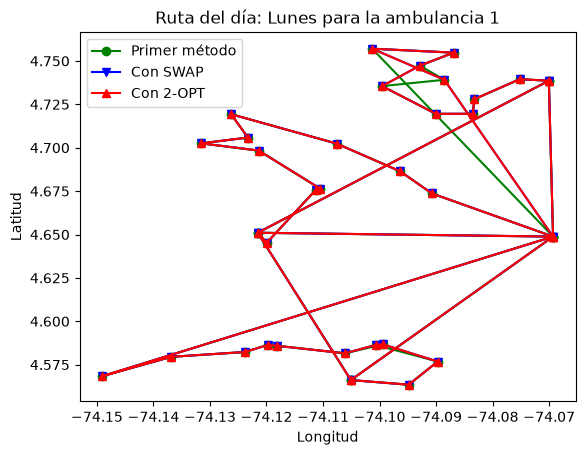

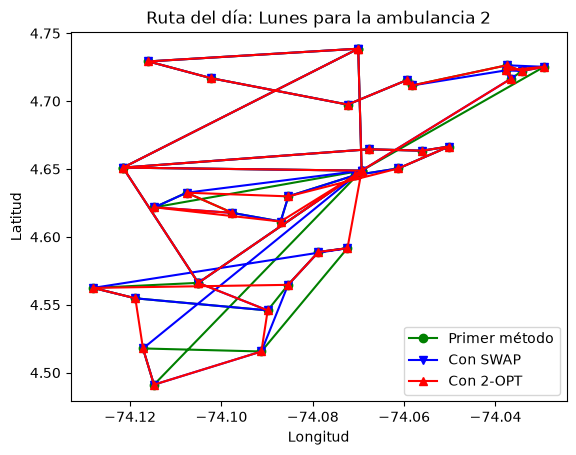

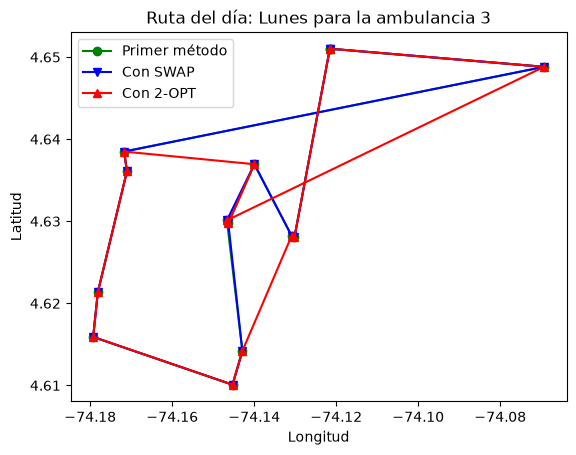

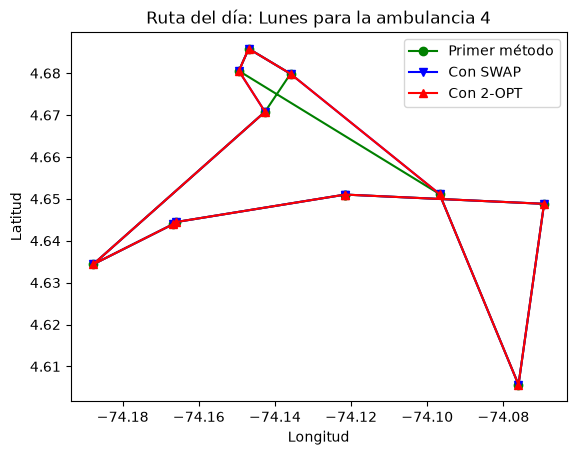

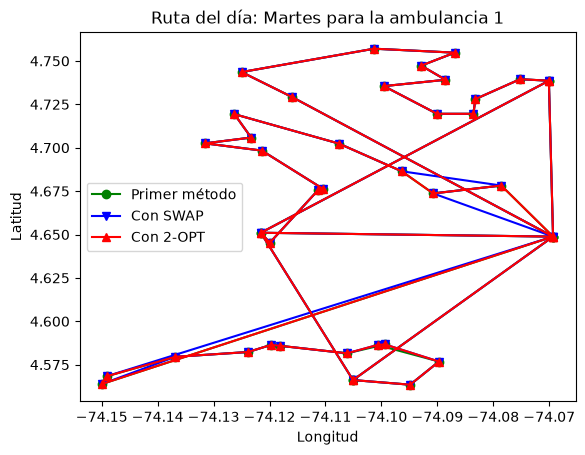

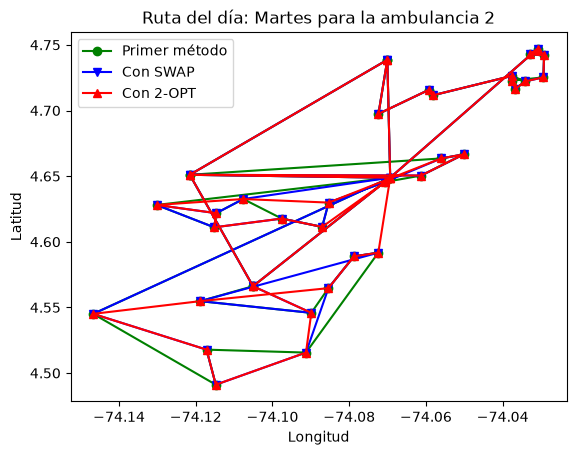

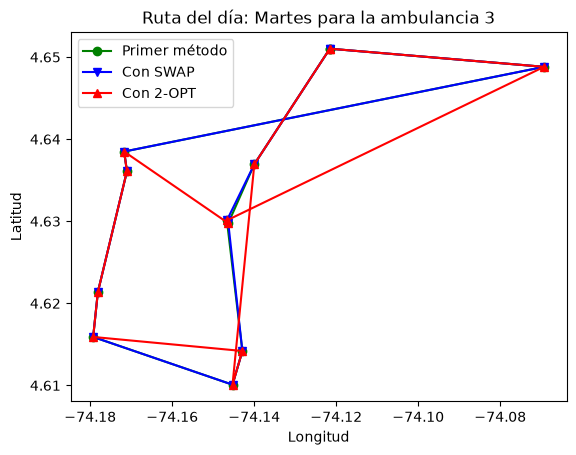

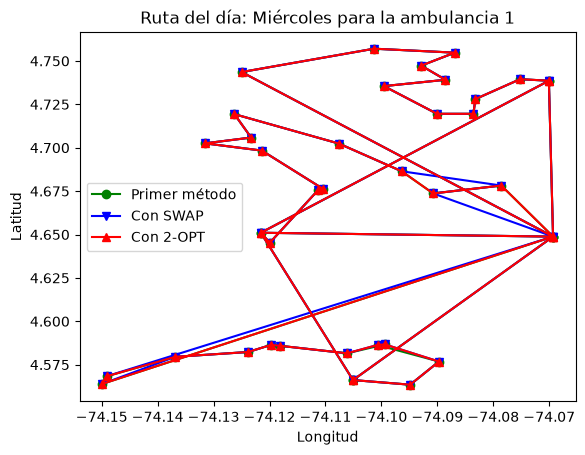

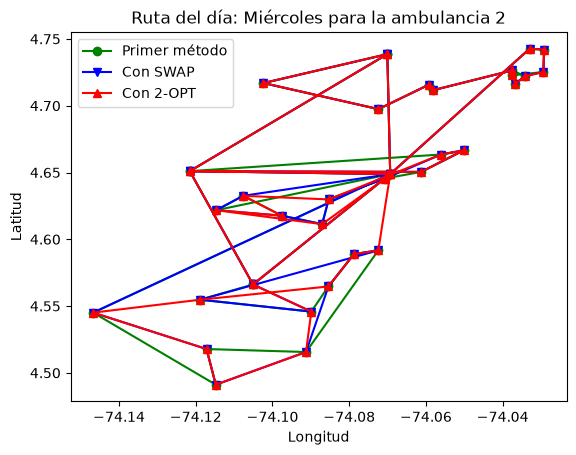

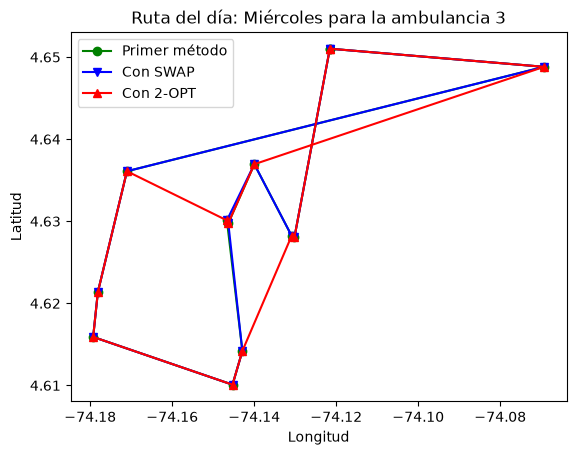

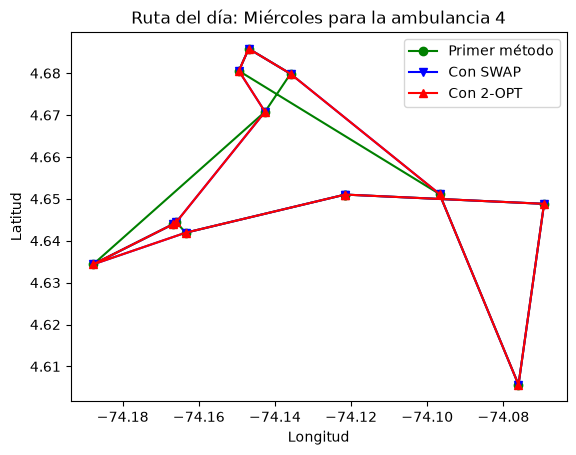

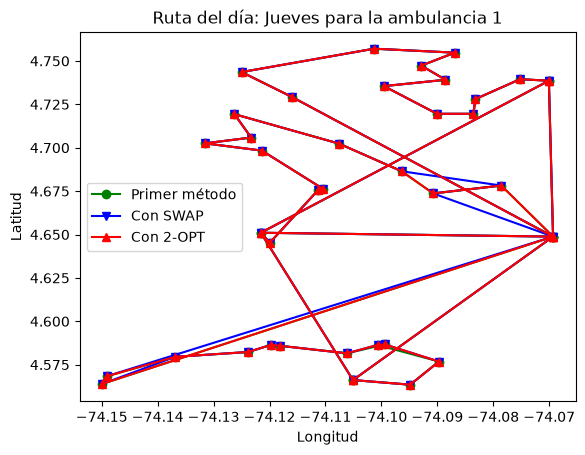

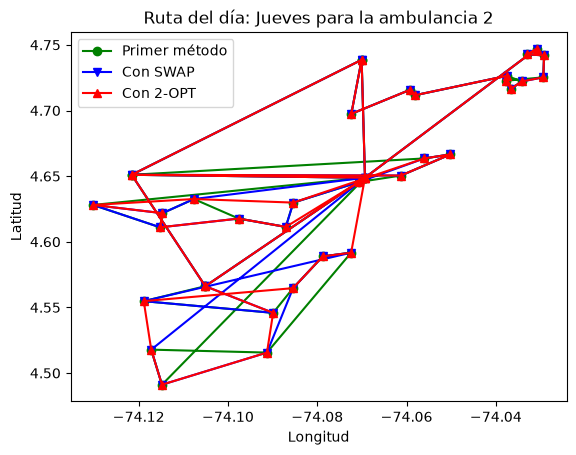

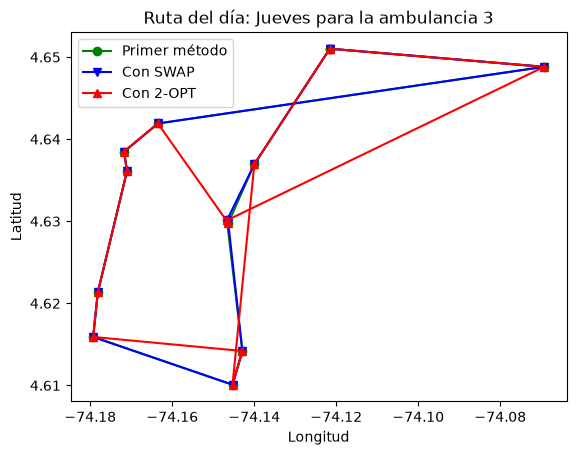

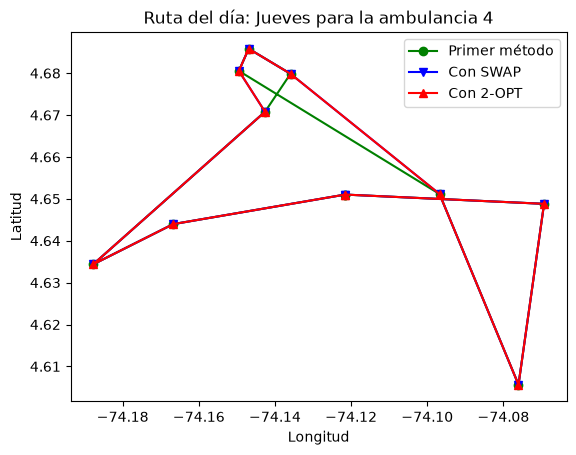

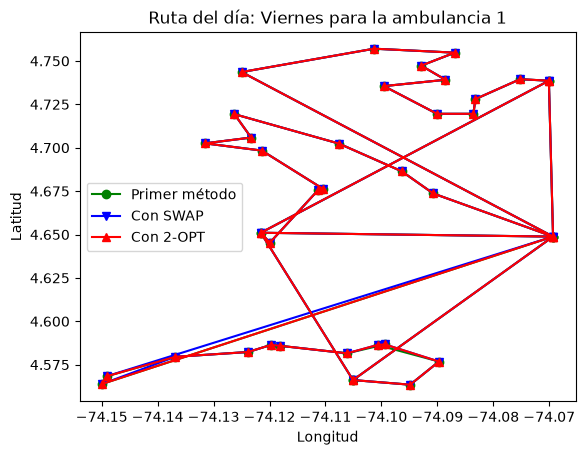

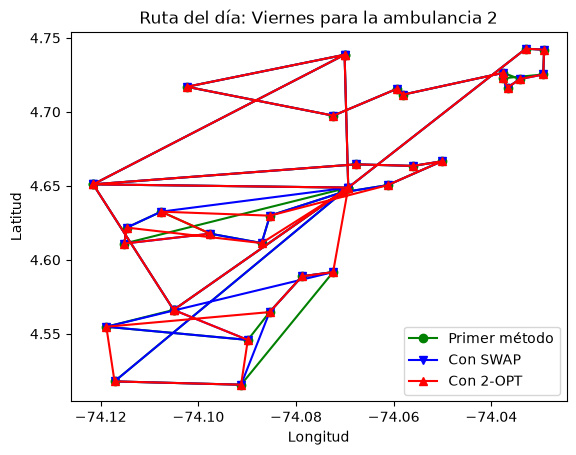

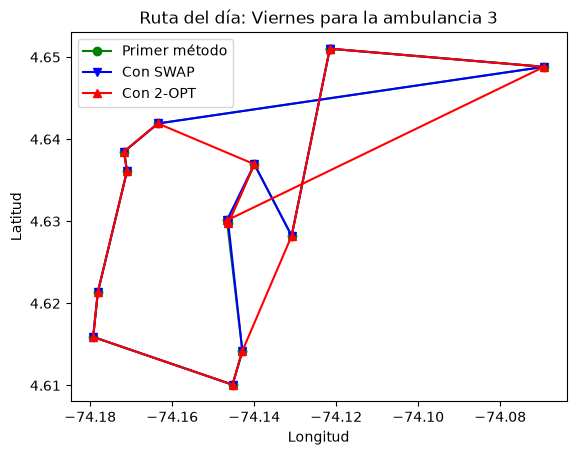

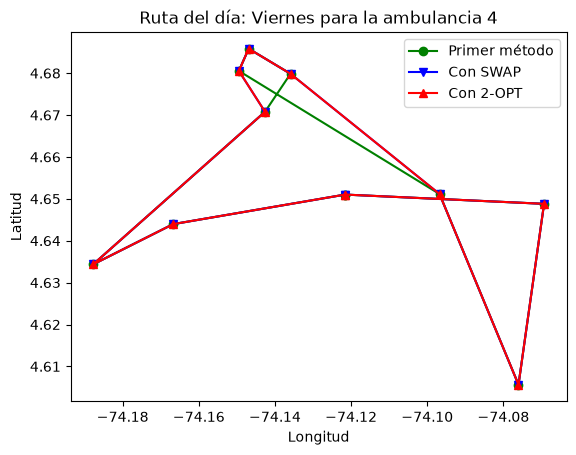

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

########## GRAFICAS ##################

soluciones = [rutas_optmizadas, rutas_optmizadas_2, rutas_optmizadas_3]
tipsol = []
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']

for sol in soluciones:
    partes_list = [partes[1] for partes in sol]      
    if partes_list:
        prueba = pd.concat(partes_list, ignore_index=True)
    else:
        prueba = pd.DataFrame()
    tipsol.append(prueba)


for dia in dias:
    cantrut = tipsol[0].loc[tipsol[0]['día'] == dia, 'ruta'].unique().tolist()
    for ruta in cantrut:
        X, Y, X1, Y1, X2, Y2 = [], [], [], [], [], []

        lista1 = tipsol[0].loc[(tipsol[0]['día'] == dia) &
                               (tipsol[0]['ruta'] == ruta), 'cliente'].tolist()
        lista2 = tipsol[1].loc[(tipsol[1]['día'] == dia) &
                               (tipsol[1]['ruta'] == ruta), 'cliente'].tolist()
        lista3 = tipsol[2].loc[(tipsol[2]['día'] == dia) &
                               (tipsol[2]['ruta'] == ruta), 'cliente'].tolist()


        n = min(len(lista1), len(lista2), len(lista3))
        for i in range(n):
            c1, c2, c3 = lista1[i], lista2[i], lista3[i]

            X.append(pacientes.loc[c1, 'Longitud'])
            Y.append(pacientes.loc[c1, 'Latitud'])

            X1.append(pacientes.loc[c2, 'Longitud'])
            Y1.append(pacientes.loc[c2, 'Latitud'])

            X2.append(pacientes.loc[c3, 'Longitud'])
            Y2.append(pacientes.loc[c3, 'Latitud'])


        plt.figure()  
        plt.plot(X,  Y,  'o-', color='g', label='Primer método')
        plt.plot(X1, Y1, 'v-', color='b', label='Con SWAP')
        plt.plot(X2, Y2, '^-', color='r', label='Con 2-OPT')

        plt.ylabel('Latitud')
        plt.xlabel('Longitud')
        plt.title(f'Ruta del día: {dia} para la ambulancia {ruta}')
        plt.legend()
        # plt.savefig(f'{dia}{ruta}.png')
        plt.show()

In [16]:
import os
from datetime import datetime
import pandas as pd

base = "DATOSPROYECTO"
path = f"{base}.xlsx"

try:
    # Intenta borrar el archivo si existe
    if os.path.exists(path):
        os.remove(path)
except PermissionError:
    # Si está bloqueado (Excel abierto), guarda con otro nombre
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    path = f"{base}_{ts}.xlsx"
    print(f"⚠ El archivo estaba bloqueado. Guardando como: {path}")

with pd.ExcelWriter(path, engine='openpyxl', mode='w') as writer:
    tabdistan.to_excel(writer, sheet_name='rutas iniciales')
    rta_subrutas.to_excel(writer, sheet_name='Sol inicial')
    rta_rutas_optmizadas.to_excel(writer, sheet_name='asig inicial')
    rta_rutas_optmizadas_costos.to_excel(writer, sheet_name='costos asig ini')
    rta_rutas_optmizadas_2.to_excel(writer, sheet_name='ruta luego de SWAP')
    rta_rutas_optmizadas_costos_2.to_excel(writer, sheet_name='costo ruta SWAP')
    rta_rutas_optmizadas_3.to_excel(writer, sheet_name='ruta optmizada con 2OPT')
    rta_rutas_optmizadas_costos_3.to_excel(writer, sheet_name='costo ruta 2OPT')

print(f"✅ Guardado en: {os.path.abspath(path)}")

✅ Guardado en: c:\Users\joseg\Downloads\PROYECTO_HEUR\PROYECTO_HEUR\DATOSPROYECTO.xlsx
